# CME538 — Introduction to Data Science
## Tutorial 8 — Classification, Evaluation & Cross-Validation

### Prediction of Rain Tomorrow

In this tutorial, we will build a machine learning model to predict whether it will rain tomorrow using weather observations from Australia.

Because the target has two possible outcomes  **Yes** or **No** this is a **binary classification** problem.

By the end of this tutorial, we will be able to:

1. Understand classification as a prediction problem.
2. Fit a logistic regression classifier.
3. Interpret predicted probabilities.
4. Convert probabilities into class predictions using a threshold.
5. Evaluate a classifier using accuracy, precision, recall, F1-score, and a confusion matrix.
6. Visualize classifier performance using ROC and precision-recall curves.
7. Understand decision boundaries.
8. Use cross-validation to estimate model performance.
9. Tune logistic regression hyperparameters.
10. Understand why class imbalance can make accuracy misleading.

### Tutorial structure

1. [Setup](#setup)
2. [Explore the data](#explore)
3. [Prepare the data](#prepare)
4. [Train a logistic regression classifier](#training)
5. [Probabilities and thresholding](#probabilities)
6. [Evaluate the classifier](#evaluation)
7. [Visual evaluation](#visual)
8. [Cross-validation and hyperparameter tuning](#cv)
9. [Class imbalance](#imbalance)
10. [Summary](#summary)

## 1. Classification problem

Suppose our client wants to know whether it will rain tomorrow.

We can represent this as:

$$
X \rightarrow y
$$

where:

- $X$ represents the weather measurements available today.
- $y$ represents whether it rains tomorrow.

Our target variable is `RainTomorrow`.

This is a **classification** problem because the target represents a category rather than a continuous numerical value.

In this tutorial, there are two classes:

$$
y \in \{\text{No}, \text{Yes}\}
$$

This makes the problem a **binary classification** problem.

### Classification versus regression

In regression, we predict a numerical quantity such as:

> What will the car price be?

In classification, we predict a category such as:

> Will it rain tomorrow?

<a id="setup"></a>

## 1. Setup

We begin by importing the packages required for data manipulation, visualization, preprocessing, model fitting, and evaluation.

This tutorial uses a modern scikit-learn workflow based on `Pipeline` and `ColumnTransformer`.

This is preferable to manually transforming the training and test sets because it helps ensure that preprocessing is learned from the training data only.

In [1]:
# NumPy provides numerical operations and array functionality.
import numpy as np

# Pandas is used for loading and manipulating tabular data.
import pandas as pd

# Matplotlib and Seaborn are used for visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# Used to split the dataset into training and test sets.
from sklearn.model_selection import train_test_split

# ColumnTransformer allows us to apply different preprocessing
# steps to numerical and categorical variables.
from sklearn.compose import ColumnTransformer

# Pipeline keeps preprocessing and model fitting together.
from sklearn.pipeline import Pipeline

# Impute missing values using statistics learned from the training data.
from sklearn.impute import SimpleImputer

# Standardize numerical features.
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Logistic regression is our classification model.
from sklearn.linear_model import LogisticRegression

# Classification metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

# Cross-validation and hyperparameter tuning.
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

# Reproducibility.
RANDOM_STATE = 52

# Make plots easier to read.
sns.set_theme(style="whitegrid")

<a id="explore"></a>

## 2. Explore the data

We use the `weatherAUS.csv` dataset.

Each row represents a weather observation at a particular location and date.

Our target variable is:

- `RainTomorrow` — whether it rained the following day.

The remaining columns contain weather measurements that may help predict this outcome.

In [2]:
# Load the weather dataset.
df = pd.read_csv("weatherAUS.csv")

# Display the first five observations.
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


### Inspect the dataset

Before fitting a model, we should understand:

- how many observations we have,
- which variables are available,
- which variables are numerical,
- which variables are categorical,
- and where missing values occur.

In [3]:
# Display the number of rows and columns.
print("Shape:", df.shape)

# Display column names, data types, and non-null counts.
df.info()

# Count missing values in each column.
df.isna().sum().sort_values(ascending=False).head(15)

Shape: (145460, 23)
<class 'pandas.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  str    
 1   Location       145460 non-null  str    
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  str    
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  str    
 10  WindDir3pm     141232 non-null  str    
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572

Sunshine         69835
Evaporation      62790
Cloud3pm         59358
Cloud9am         55888
Pressure9am      15065
Pressure3pm      15028
WindDir9am       10566
WindGustDir      10326
WindGustSpeed    10263
Humidity3pm       4507
WindDir3pm        4228
Temp3pm           3609
RainTomorrow      3267
Rainfall          3261
RainToday         3261
dtype: int64

### The target variable

Our target is `RainTomorrow`.

Since the target has two classes, this is a **binary classification** problem.

We first remove observations where the target itself is missing. A model cannot learn whether tomorrow will rain if the answer is unknown.

In [4]:
# Remove observations where the target value is missing.
df = df.dropna(subset=["RainTomorrow"]).copy()

# Examine the available target classes.
print(df["RainTomorrow"].value_counts())

# Show the proportion of each class.
print("\nClass proportions:")
print(df["RainTomorrow"].value_counts(normalize=True))

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

Class proportions:
RainTomorrow
No     0.775819
Yes    0.224181
Name: proportion, dtype: float64


### Class distribution

It is useful to visualize the target distribution.

This will also introduce an important issue later in the tutorial: **class imbalance**.

If one class is much more common than the other, a model can achieve high accuracy simply by predicting the majority class most of the time.

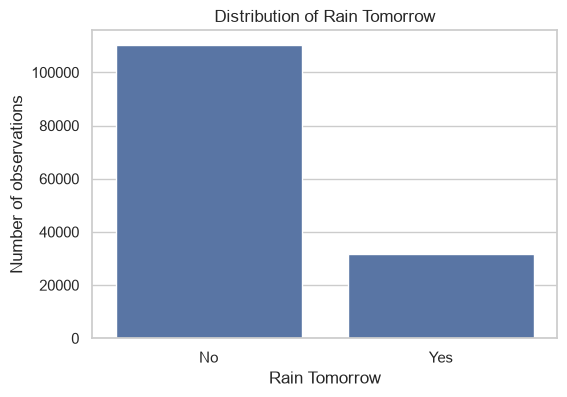

In [5]:
# Plot the number of observations in each target class.
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="RainTomorrow")

plt.title("Distribution of Rain Tomorrow")
plt.xlabel("Rain Tomorrow")
plt.ylabel("Number of observations")

plt.show()

## 3. Prepare the data

Machine learning models require numerical inputs.

Our dataset contains both:

- **numerical variables**, such as temperature and pressure;
- **categorical variables**, such as location and wind direction.

We will also extract useful information from the date.

Rather than manually transforming the training and test sets, we will use a scikit-learn preprocessing pipeline.

In [6]:
# Convert Date from text into a datetime object.
df["Date"] = pd.to_datetime(df["Date"])

# Extract useful components of the date.
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# The original Date column is no longer needed.
df = df.drop(columns=["Date"])

# Separate predictors from the target.
X = df.drop(columns=["RainTomorrow"])
y = df["RainTomorrow"]

# Display the target and feature dimensions.
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (142193, 24)
y shape: (142193,)


### Train-test split

We now separate the data into:

- **training data** — used to learn the model;
- **test data** — held back until the end to estimate performance on unseen observations.

We use `stratify=y` so that the proportion of Rain/No Rain observations is approximately preserved in both sets.

In [7]:
# Split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Display the resulting sizes.
print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

# Compare class proportions in the two sets.
print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True))

Training observations: 113754
Test observations: 28439

Training class proportions:
RainTomorrow
No     0.775814
Yes    0.224186
Name: proportion, dtype: float64

Test class proportions:
RainTomorrow
No     0.775836
Yes    0.224164
Name: proportion, dtype: float64


### Identify numerical and categorical features

We will let the preprocessing pipeline handle:

- missing numerical values using the median;
- missing categorical values using the most frequent category;
- scaling of numerical variables;
- one-hot encoding of categorical variables.

This avoids manually modifying the test set using information calculated from the test data.

In [8]:
# Identify numerical columns.
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical columns.
categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 16
Number of categorical features: 5

Numerical features:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Categorical features:
['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


/var/folders/xp/d135v_b95tjfjg799lh0fdrw0000gn/T/ipykernel_37182/1784138896.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


### Build the preprocessing pipeline

We create two preprocessing pipelines.

For numerical variables:

1. Replace missing values with the training-set median.
2. Standardize the variables.

For categorical variables:

1. Replace missing values with the most frequent category.
2. Convert categories into one-hot encoded variables.

The `ColumnTransformer` applies the appropriate pipeline to each type of feature.

In [9]:
# Numerical preprocessing:
# - median imputation handles missing numerical values;
# - StandardScaler puts numerical variables on a comparable scale.
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# - most_frequent imputation handles missing categories;
# - OneHotEncoder converts categories into 0/1 indicators.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate preprocessing to each feature type.
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

<a id="training"></a>

## 4. Train a Logistic Regression Classifier

Logistic regression is a classification model that estimates the probability of belonging to a class.

For binary classification, the model estimates:

$$
P(Y=1\mid X)
$$

The logistic function converts the model's linear score into a probability between 0 and 1.

Unlike ordinary linear regression, logistic regression is designed for a categorical target.

In [10]:
# Create the complete machine learning pipeline.
# Preprocessing happens first, followed by logistic regression.
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

# Fit the entire pipeline using the training data.
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['Location','MinTemp','MaxTemp',...,'Year','Month','Day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

## 5. Classification versus regression

The key difference is the type of prediction.

### Regression

Predicts a numerical quantity:

$$
\hat{y} = 52,000
$$

For example, predicting a car price.

### Classification

Predicts a class:

$$
\hat{y} = \text{Yes}
$$

For example, predicting whether it will rain tomorrow.

However, a classifier can also provide a **probability** rather than only a class label.

<a id="probabilities"></a>

## 6. Predicted probabilities and thresholding

A classifier does not fundamentally have to say only "Yes" or "No".

For each observation, logistic regression can estimate:

$$
P(\text{RainTomorrow}=\text{Yes}\mid X)
$$

For example:

- probability = 0.10 → low chance of rain
- probability = 0.55 → moderate chance of rain
- probability = 0.90 → high chance of rain

To convert probabilities into class predictions, we use a **threshold**.

The default threshold is usually 0.50.

In [11]:
# Predict the probability of each class on the test set.
probabilities = logistic_model.predict_proba(X_test)

# Display the first five probability predictions.
probabilities[:5]

array([[0.87570637, 0.12429363],
       [0.88419901, 0.11580099],
       [0.98343779, 0.01656221],
       [0.93904762, 0.06095238],
       [0.99702271, 0.00297729]])

In [12]:
# Identify which probability column corresponds to "Yes".
class_labels = logistic_model.classes_

print("Class order:", class_labels)

# Find the column corresponding to RainTomorrow = Yes.
yes_index = list(class_labels).index("Yes")

# Extract the probability of rain.
y_prob = probabilities[:, yes_index]

# Display the first ten probabilities.
y_prob[:10]

Class order: ['No' 'Yes']


array([0.12429363, 0.11580099, 0.01656221, 0.06095238, 0.00297729,
       0.06652471, 0.27059855, 0.69802829, 0.03264532, 0.19851311])

### Changing the classification threshold

With a threshold of 0.50:

$$
P(\text{Rain}) \geq 0.50
\Rightarrow \text{predict Yes}
$$

Otherwise, we predict No.

But 0.50 is not always the best threshold.

For example, if missing a rainy day is especially costly, we may prefer a lower threshold so that the model predicts "Yes" more often.

In [13]:
# Convert probabilities into predictions using the default 0.50 threshold.
y_pred_50 = np.where(
    y_prob >= 0.50,
    "Yes",
    "No"
)

# Display the first ten predictions.
y_pred_50[:10]

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No'],
      dtype='<U3')

<a id="evaluation"></a>

## 7. Evaluating a classifier

A classifier can make four types of predictions:

| | Actual No | Actual Yes |
|---|---:|---:|
| Predicted No | True Negative (TN) | False Negative (FN) |
| Predicted Yes | False Positive (FP) | True Positive (TP) |

These four values form the **confusion matrix**.

Different metrics emphasize different types of errors.

In [14]:
# Calculate the confusion matrix.
cm = confusion_matrix(
    y_test,
    y_pred_50,
    labels=["No", "Yes"]
)

# Display the matrix.
print(cm)

[[20808  1256]
 [ 3069  3306]]


### Accuracy

Accuracy is the proportion of predictions that are correct:

$$
Accuracy =
\frac{TP+TN}{TP+TN+FP+FN}
$$

Accuracy is easy to understand, but it can be misleading when classes are imbalanced.

In [15]:
# Calculate test-set accuracy.
accuracy = accuracy_score(y_test, y_pred_50)

print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.848


### Precision, Recall and F1-score

For the positive class, "Yes":

**Precision**

Of the observations predicted as Yes, how many actually were Yes?

$$
Precision = \frac{TP}{TP+FP}
$$

**Recall**

Of the observations that actually were Yes, how many did we correctly identify?

$$
Recall = \frac{TP}{TP+FN}
$$

**F1-score**

The harmonic mean of precision and recall:

$$
F1 = 2\frac{Precision\cdot Recall}
{Precision+Recall}
$$

There is usually a trade-off between precision and recall.

In [16]:
# Calculate precision, recall, and F1-score for the Rain = Yes class.
precision = precision_score(
    y_test,
    y_pred_50,
    pos_label="Yes"
)

recall = recall_score(
    y_test,
    y_pred_50,
    pos_label="Yes"
)

f1 = f1_score(
    y_test,
    y_pred_50,
    pos_label="Yes"
)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Precision: 0.725
Recall:    0.519
F1-score:  0.605


In [17]:
# classification_report provides several useful metrics at once.
print(classification_report(y_test, y_pred_50))

              precision    recall  f1-score   support

          No       0.87      0.94      0.91     22064
         Yes       0.72      0.52      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.80      0.73      0.76     28439
weighted avg       0.84      0.85      0.84     28439



## 8. Confusion matrix visualization

A confusion matrix is often easier to interpret visually.

The rows represent the **actual** class and the columns represent the **predicted** class.

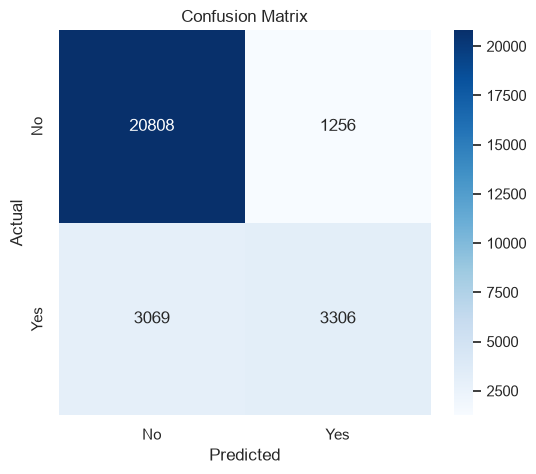

In [18]:
# Create a heatmap of the confusion matrix.
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

<a id="visual"></a>

## 9. Visual metrics: ROC curve and AUC

The ROC curve evaluates the classifier over many possible probability thresholds.

It plots:

- **True Positive Rate (TPR)** against
- **False Positive Rate (FPR)**.

The area under the ROC curve is called **ROC-AUC**.

A value close to:

- 1 → strong discrimination;
- 0.5 → approximately random ranking.

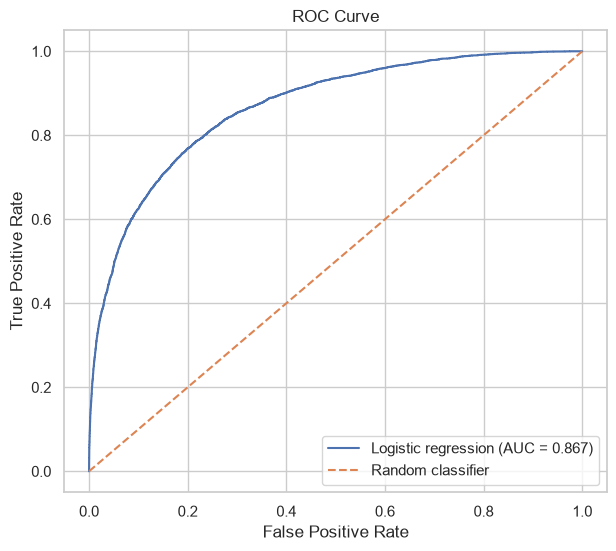

In [19]:
# Calculate the false-positive and true-positive rates
# across many possible probability thresholds.
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

# Calculate the area under the ROC curve.
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# Plot the ROC curve.
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic regression (AUC = {roc_auc:.3f})"
)

# Random guessing corresponds approximately to this diagonal.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

### Precision-recall curve

When the positive class is relatively uncommon, the precision-recall curve can be especially informative.

It shows the trade-off between:

- precision;
- recall;

as the classification threshold changes.

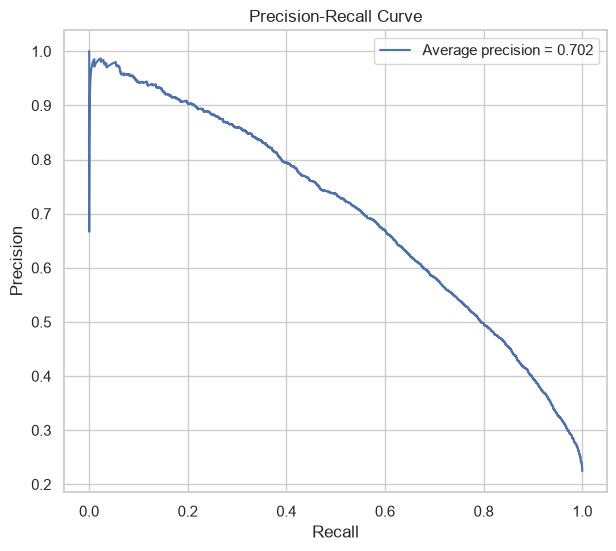

In [20]:
# Calculate precision and recall at different thresholds.
precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob,
    pos_label="Yes"
)

# Calculate average precision.
average_precision = average_precision_score(
    y_test,
    y_prob,
    pos_label="Yes"
)

# Plot the precision-recall curve.
plt.figure(figsize=(7, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"Average precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

## 10. Decision boundaries

A classifier separates observations into different classes.

For a linear classifier such as logistic regression, the decision boundary is determined by:

$$
\theta_0+\theta_1x_1+\cdots+\theta_px_p = 0
$$

For two features, this corresponds to a line.

One side of the boundary is classified as one class, while the other side is classified as the other class.

In this tutorial we have many features, so the boundary exists in a higher-dimensional feature space and cannot be directly drawn as a simple 2-D line.

<a id="cv"></a>

### 11. Cross-validation with classification metrics

We use **StratifiedKFold** so that each fold maintains approximately the
same proportion of the target classes.

Because our target variable contains the labels `"No"` and `"Yes"`, we
must explicitly tell the precision, recall, and F1 scorers that `"Yes"`
is the positive class.

This is important because these metrics depend on which class is treated
as the positive class.

In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# StratifiedKFold preserves the class proportions in each fold.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# ---------------------------------------------------------
# Define the positive class explicitly.
#
# Our target contains "No" and "Yes", so we define "Yes"
# as the positive class for precision, recall, and F1.
# ---------------------------------------------------------

precision_scorer = make_scorer(
    precision_score,
    pos_label="Yes"
)

recall_scorer = make_scorer(
    recall_score,
    pos_label="Yes"
)

f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

# ---------------------------------------------------------
# Evaluate the classification model using cross-validation.
#
# ROC AUC is calculated from the model's probability scores,
# while precision/recall/F1 use "Yes" as the positive class.
# ---------------------------------------------------------

cv_results = cross_validate(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": precision_scorer,
        "recall": recall_scorer,
        "f1": f1_scorer,
        "roc_auc": "roc_auc"
    }
)

# ---------------------------------------------------------
# Display the mean and standard deviation for each metric.
#
# Mean = average performance across the five folds.
# Standard deviation = how much performance varies between folds.
# ---------------------------------------------------------

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]

    print(
        f"{metric:10s}: "
        f"{scores.mean():.3f} ± {scores.std():.3f}"
    )

accuracy  : 0.848 ± 0.003
precision : 0.730 ± 0.010
recall    : 0.511 ± 0.006
f1        : 0.601 ± 0.006
roc_auc   : 0.871 ± 0.003


## 12. Hyperparameter tuning

Logistic regression has hyperparameters that control model complexity.

One important hyperparameter is `C`.

`C` controls the strength of regularization:

- smaller `C` → stronger regularization;
- larger `C` → weaker regularization.

Instead of choosing `C` arbitrarily, we can evaluate several values using cross-validation.

In [22]:
# Define candidate values of the regularization parameter C.
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

# GridSearchCV evaluates each candidate using cross-validation.
grid_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1
)

# Fit the grid search using training data only.
grid_search.fit(X_train, y_train)

# Display the best hyperparameter and cross-validation score.
print("Best parameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.3f}")

Best parameters: {'classifier__C': 0.1}
Best CV ROC-AUC: 0.871


### Final test-set evaluation

The test set has not been used to choose the model or hyperparameters.

We can therefore use it once to obtain our final estimate of generalization performance.

In [23]:
# Generate test-set probabilities using the best model.
y_prob_best = grid_search.predict_proba(X_test)[:, yes_index]

# Convert probabilities into class predictions using a 0.50 threshold.
y_pred_best = np.where(
    y_prob_best >= 0.50,
    "Yes",
    "No"
)

# Evaluate the final model on unseen test data.
print("Test Accuracy:",
      round(accuracy_score(y_test, y_pred_best), 3))

print("Test Precision:",
      round(precision_score(y_test, y_pred_best, pos_label="Yes"), 3))

print("Test Recall:",
      round(recall_score(y_test, y_pred_best, pos_label="Yes"), 3))

print("Test F1:",
      round(f1_score(y_test, y_pred_best, pos_label="Yes"), 3))

print("Test ROC-AUC:",
      round(roc_auc_score(y_test, y_prob_best), 3))

Test Accuracy: 0.848
Test Precision: 0.724
Test Recall: 0.517
Test F1: 0.603
Test ROC-AUC: 0.867


<a id="imbalance"></a>

## 13. Class imbalance

Our target is not perfectly balanced: there are more "No" observations than "Yes" observations.

This matters because accuracy can hide poor performance on the minority class.

For example, imagine that:

- 90% of observations are No;
- 10% are Yes.

A classifier that always predicts No would have 90% accuracy while detecting **zero** rainy days.

Therefore, when classes are imbalanced, we should consider metrics such as:

- precision;
- recall;
- F1-score;
- ROC-AUC;
- precision-recall curves.

The appropriate metric depends on the cost of different errors.

In [24]:
# Calculate the accuracy of a naive majority-class classifier.
majority_class = y_train.mode()[0]

majority_predictions = np.repeat(
    majority_class,
    len(y_test)
)

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)

print("Majority class:", majority_class)
print(f"Majority-class accuracy: {majority_accuracy:.3f}")

Majority class: No
Majority-class accuracy: 0.776


### Class weighting

One way to make logistic regression pay more attention to the minority class is to use:

```text
class_weight="balanced"
```

In [25]:

# Create a version of the model that automatically gives
# more weight to the minority class.
balanced_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

# Fit the balanced model using training data.
balanced_model.fit(X_train, y_train)

# Generate probabilities and predictions.
balanced_prob = balanced_model.predict_proba(X_test)[:, yes_index]

balanced_pred = np.where(
    balanced_prob >= 0.50,
    "Yes",
    "No"
)

# Compare classification performance.
print("Balanced model")
print("-----------------------------")
print(
    f"Accuracy:  {accuracy_score(y_test, balanced_pred):.3f}"
)
print(
    f"Precision: {precision_score(y_test, balanced_pred, pos_label='Yes'):.3f}"
)
print(
    f"Recall:    {recall_score(y_test, balanced_pred, pos_label='Yes'):.3f}"
)
print(
    f"F1:        {f1_score(y_test, balanced_pred, pos_label='Yes'):.3f}"
)

Balanced model
-----------------------------
Accuracy:  0.791
Precision: 0.523
Recall:    0.775
F1:        0.624


## 14. Threshold trade-off

The default threshold of 0.50 is only one possible choice.

A lower threshold generally makes the classifier predict "Yes" more often:

- recall tends to increase;
- precision may decrease.

A higher threshold generally makes the classifier more conservative:

- precision may increase;
- recall may decrease.

The appropriate threshold should therefore depend on the application and the relative cost of false positives and false negatives.

In [26]:
# Examine how the threshold changes precision and recall.
thresholds_to_try = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_results = []

for threshold in thresholds_to_try:

    # Convert probabilities to class predictions.
    predictions = np.where(
        y_prob_best >= threshold,
        "Yes",
        "No"
    )

    # Calculate metrics for this threshold.
    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test,
            predictions,
            pos_label="Yes"
        ),
        "recall": recall_score(
            y_test,
            predictions,
            pos_label="Yes"
        ),
        "f1": f1_score(
            y_test,
            predictions,
            pos_label="Yes"
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,threshold,precision,recall,f1
0,0.2,0.498239,0.798902,0.613725
1,0.3,0.585643,0.696157,0.636136
2,0.4,0.659318,0.609882,0.633638
3,0.5,0.724236,0.517020,0.603332
4,0.6,0.777011,0.424157,0.548757
5,0.7,0.841663,0.330196,0.474313
6,0.8,0.892205,0.229804,0.365473


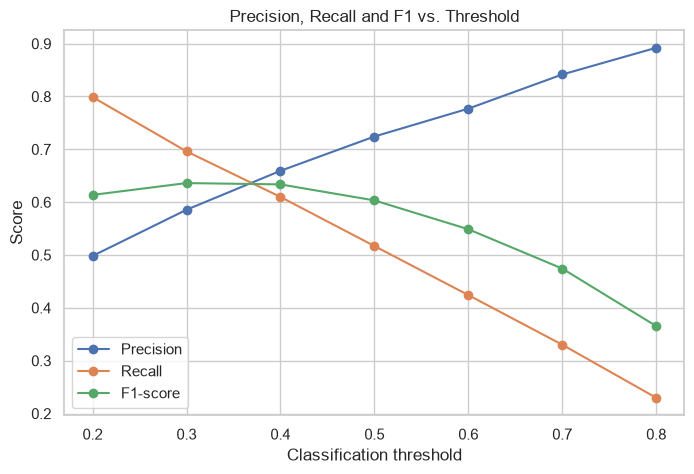

In [27]:
# Plot precision and recall as the classification threshold changes.
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs. Threshold")
plt.legend()

plt.show()